# Otis Capture-Recapture Analysis


In [11]:
import math
from pathlib import Path
from typing import Dict
from IPython.display import display, Markdown

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, special


# Define Data Reading and Processing Functions


In [12]:
def read_mark_histories(path: Path) -> pd.DataFrame:
    raw_lines = [
        line.strip()
        for line in path.read_text(encoding="utf-8", errors="replace").splitlines()
        if line.strip() and not line.lstrip().startswith("#")
    ]
    rows = []
    for line in raw_lines:
        parts = line.split()
        if len(parts) >= 2 and parts[-1] == ";":
            hist = parts[0]
            count = int(parts[1])
            rows.append((hist, count))
    return pd.DataFrame(rows, columns=["history", "count"])

def two_sample_counts(df: pd.DataFrame, i1: int = 0, i2: int = 1) -> Dict[str, int]:
    hist = df["history"].astype(str)
    c = df["count"].astype(int)
    cap1 = hist.str[i1] == "1"
    cap2 = hist.str[i2] == "1"
    return {
        "n1": int(c[cap1].sum()),
        "n2": int(c[cap2].sum()),
        "m2": int(c[cap1 & cap2].sum()),
    }

def subset_histories(df: pd.DataFrame, indices: list[int]) -> pd.DataFrame:
    hist = df["history"].astype(str)
    counts = df["count"].astype(int)
    rows = [
        ("".join(h[i] for i in indices), int(c))
        for h, c in zip(hist, counts)
    ]
    return pd.DataFrame(rows, columns=["history", "count"])


# Define Lincoln-Petersen and Capture-Recapture Models


In [15]:
def print_pair_lp(observed_sub: pd.DataFrame, pairs: list[tuple[int, int, str]]) -> pd.DataFrame:
    rows = []
    for i1, i2, label in pairs:
        counts_pair = two_sample_counts(observed_sub, i1, i2)
        lp_sub = lincoln_petersen(counts_pair["n1"], counts_pair["n2"], counts_pair["m2"])
        rows.append({
            "Pár": label,
            "n1": counts_pair["n1"],
            "n2": counts_pair["n2"],
            "m2": counts_pair["m2"],
            "LP N_hat": round(lp_sub["N_lp"], 1),
            "Chapman N_hat": round(lp_sub["N_chapman"], 1),
            "Chapman VAR": round(lp_sub["VAR_chapman"], 1),
            "Chapman 95% CI lower": round(lp_sub["CI_lower"], 1),
            "Chapman 95% CI upper": round(lp_sub["CI_upper"], 1),
        })
    return pd.DataFrame(rows)

def lincoln_petersen(n1: int, n2: int, m2: int) -> Dict[str, float]:
    if m2 <= 0:
        raise ValueError("m2 musí byť kladné pre odhad.")
    N_lp = n1 * n2 / m2
    N_chapman = (n1 + 1) * (n2 + 1) / (m2 + 1) - 1
    VAR_chapman = (n1 + 1) * (n2 + 1) * (n1 - m2) * (n2 - m2) / (((m2 + 1) ** 2) * (m2 + 2))
    se = math.sqrt(VAR_chapman)
    CI_lower = N_chapman - 1.96 * se
    CI_upper = N_chapman + 1.96 * se
    return {
        "N_lp": N_lp,
        "N_chapman": N_chapman,
        "VAR_chapman": VAR_chapman,
        "CI_lower": max(0, CI_lower),
        "CI_upper": CI_upper,
    }


# Define Model Fitting and AIC Comparison


In [19]:
def log_likelihood_m0(N: int, n_obs: int, total_captures: int, T: int) -> float:
    if N < n_obs:
        return -np.inf
    p = total_captures / (N * T)
    if p <= 0 or p >= 1:
        return -np.inf
    log_mult = special.gammaln(N + 1) - special.gammaln(N - n_obs + 1)
    log_prob = total_captures * math.log(p) + (N * T - total_captures) * math.log(1 - p)
    return float(log_mult + log_prob)

def fit_m0(n_obs: int, total_captures: int, T: int, N_max: int) -> Dict[str, object]:
    best = {"N": n_obs, "p": None, "logLik": -np.inf}
    for N in range(n_obs, N_max + 1):
        ll = log_likelihood_m0(N, n_obs, total_captures, T)
        if ll > best["logLik"]:
            best.update({"N": N, "p": total_captures / (N * T), "logLik": ll})
    return best

def fit_mt(n_obs: int, counts_by_time: list[int], T: int, N_max: int) -> Dict[str, object]:
    best = {"N": n_obs, "p": None, "logLik": -np.inf}
    for N in range(n_obs, N_max + 1):
        p = [count / N for count in counts_by_time]
        if any(pi <= 0 or pi >= 1 for pi in p):
            continue
        log_mult = special.gammaln(N + 1) - special.gammaln(N - n_obs + 1)
        log_prob = sum(count * math.log(pi) + (N - count) * math.log(1 - pi) for count, pi in zip(counts_by_time, p))
        ll = float(log_mult + log_prob)
        if ll > best["logLik"]:
            best.update({"N": N, "p": p, "logLik": ll})
    return best

def log_prob_mb(history: str, p: float, c: float) -> float:
    if p <= 0 or p >= 1 or c <= 0 or c >= 1:
        return -np.inf
    if "1" not in history:
        return len(history) * math.log(1 - p)
    first = history.index("1")
    later = history[first + 1 :]
    log_val = first * math.log(1 - p) + math.log(p)
    log_val += sum(math.log(c) if ch == "1" else math.log(1 - c) for ch in later)
    return float(log_val)

def fit_mb(histories: list[str], counts: list[int], n_obs: int, T: int, N_max: int) -> Dict[str, object]:
    best = {"N": n_obs, "p": None, "c": None, "logLik": -np.inf}
    for N in range(n_obs, N_max + 1):
        def neg_ll(params: np.ndarray) -> float:
            p, c = params
            if p <= 0 or p >= 1 or c <= 0 or c >= 1:
                return 1e12
            log_mult = special.gammaln(N + 1) - special.gammaln(N - n_obs + 1)
            log_data = sum(count * log_prob_mb(hist, p, c) for hist, count in zip(histories, counts))
            log_zero = (N - n_obs) * T * math.log(1 - p)
            return -float(log_mult + log_data + log_zero)

        result = optimize.minimize(
            neg_ll,
            x0=np.array([0.2, 0.2]),
            bounds=[(1e-6, 1 - 1e-6), (1e-6, 1 - 1e-6)],
            method="L-BFGS-B",
        )
        if not result.success:
            continue
        ll = -result.fun
        if ll > best["logLik"]:
            p_hat, c_hat = result.x
            best.update({"N": N, "p": float(p_hat), "c": float(c_hat), "logLik": float(ll)})
    return best

def compute_mh_jackknife(n_obs: int, counts_by_k: Dict[int, int], T: int) -> Dict[str, float]:
    f1 = counts_by_k.get(1, 0)
    f2 = counts_by_k.get(2, 0)
    M_unique = n_obs
    if T == 3:
        Nh1 = M_unique + 2.0 / 3.0 * f1
        Nh2 = M_unique + 1.0 * f1 - (1.0 / 6.0) * f2
    else:
        Nh1 = M_unique + ((T - 1) / T) * f1
        Nh2 = M_unique + ((2 * T - 3) / T) * f1 - (((T - 2) ** 2) / (T * (T - 1))) * f2
    return {
        "M_unique": M_unique,
        "f1": int(f1),
        "f2": int(f2),
        "Mh_jackknife1": float(Nh1),
        "Mh_jackknife2": float(Nh2),
    }


In [21]:
def compute_aic(logLik: float, num_params: int) -> float:
    return 2 * num_params - 2 * logLik

def interpret_aic_support(best_model: str, delta_by_model: dict[str, float]) -> str:
    interpretations = []
    for model, delta in delta_by_model.items():
        if model == best_model:
            continue
        if delta < 2:
            interpretations.append(f"{model}: prakticky porovnateľný (ΔAIC={delta:.1f})")
        elif delta <= 7:
            interpretations.append(f"{model}: pozorovateľne horší (ΔAIC={delta:.1f})")
        else:
            interpretations.append(f"{model}: výrazne horší (ΔAIC={delta:.1f})")
    return "; ".join(interpretations)


In [98]:
def pt_subset_otis(raw_df: pd.DataFrame, indices: list[int], name: str, N_max: int) -> dict[str, object]:
    subset = subset_histories(raw_df, indices)
    T_sub = len(indices)
    zero_hist = "0" * T_sub
    zero_count = int(subset.loc[subset["history"] == zero_hist, "count"].sum())
    observed_sub = subset.loc[subset["history"] != zero_hist].copy()

    n_obs_sub = int(observed_sub["count"].sum())
    total_captures_sub = int((observed_sub["history"].str.count("1") * observed_sub["count"]).sum())
    counts_by_time_sub = [
        int((observed_sub["history"].str[i] == "1").mul(observed_sub["count"]).sum())
        for i in range(T_sub)
    ]
    counts_by_k_sub: dict[int, int] = {}
    for hist, count in zip(observed_sub["history"].tolist(), observed_sub["count"].tolist()):
        k = hist.count("1")
        counts_by_k_sub[k] = counts_by_k_sub.get(k, 0) + count

    N_max_sub = min(N_max, n_obs_sub + 120)
    mh_jackknife = compute_mh_jackknife(n_obs_sub, counts_by_k_sub, T_sub)

    pair_df = print_pair_lp(observed_sub, [(0, 1, "1-2"), (1, 2, "2-3"), (0, 2, "1-3")])

    best_m0_sub = fit_m0(n_obs_sub, total_captures_sub, T_sub, N_max_sub)
    best_mt_sub = fit_mt(n_obs_sub, counts_by_time_sub, T_sub, N_max_sub)
    best_mb_sub = fit_mb(observed_sub["history"].tolist(), observed_sub["count"].tolist(), n_obs_sub, T_sub, N_max_sub)

    result_rows_sub = [
        ("M0", best_m0_sub["N"], best_m0_sub["logLik"], compute_aic(best_m0_sub["logLik"], 2), {"p": best_m0_sub["p"]}),
        ("Mt", best_mt_sub["N"], best_mt_sub["logLik"], compute_aic(best_mt_sub["logLik"], T_sub + 1), {"p_t": best_mt_sub["p"]}),
        ("Mb", best_mb_sub["N"], best_mb_sub["logLik"], compute_aic(best_mb_sub["logLik"], 3), {"p": best_mb_sub["p"], "c": best_mb_sub["c"]}),
    ]
    aic_values = [row[3] for row in result_rows_sub]
    min_aic = min(aic_values)
    delta_aic = [aic - min_aic for aic in aic_values]
    delta_by_model = {row[0]: delta for row, delta in zip(result_rows_sub, delta_aic)}
    best_sub = min(result_rows_sub, key=lambda row: row[3])
    interpretation = interpret_aic_support(best_sub[0], delta_by_model)

    aic_df = pd.DataFrame({
        "Model": [row[0] for row in result_rows_sub],
        "N_hat": [row[1] for row in result_rows_sub],
        "logLik": [row[2] for row in result_rows_sub],
        "AIC": [row[3] for row in result_rows_sub],
        "ΔAIC": delta_aic,
    })

    mh_df = pd.DataFrame([mh_jackknife])

    return {
        "month": name,
        "n_obs": n_obs_sub,
        "zero_count": zero_count,
        "counts_by_time": counts_by_time_sub,
        "pair_df": pair_df,
        "aic_df": aic_df,
        "mh_df": mh_df,
        "best_model": best_sub[0],
        "interpretation": interpretation,
        "result_rows": result_rows_sub,
        'best_m0' : best_m0_sub,
        "best_mt": best_mt_sub,
        'best_mb': best_mb_sub,
        "M0_N": best_m0_sub["N"],
        "Mt_N": best_mt_sub["N"],
        "Mb_N": best_mb_sub["N"],
        "AIC_M0": result_rows_sub[0][3],
        "AIC_Mt": result_rows_sub[1][3],
        "AIC_Mb": result_rows_sub[2][3],
        "deltaAIC_M0": delta_aic[0],
        "deltaAIC_Mt": delta_aic[1],
        "deltaAIC_Mb": delta_aic[2],
    }


# Define Plotting Functions


In [64]:
def plot_capture_frequency(counts_by_time: list[int], outpath: Path) -> None:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(range(1, len(counts_by_time) + 1), counts_by_time, color="tab:blue")
    #ax.set_title("Počet odchytov podľa primárnych prehliadok")
    ax.set_xlabel("Sekundárna prehliadka", fontsize=26)
    ax.set_ylabel("Počet odchytených jedincov", fontsize=26)
    ax.set_xticks(range(1, len(counts_by_time) + 1))
    ax.tick_params(axis='both', labelsize=24)
    fig.tight_layout()
    outpath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(outpath, dpi=200)
    plt.show()


# Main Analysis Execution


## Dáta z 21 sekundárnych prehliadok

**Celkový počet riadkov:** 845

**Pozorovaných jedincov (bez all-zero):** 748

**Úplne nulových histórií:** 97

**Počet prehliadok T_raw:** 21

...

Pre prvý mesiac uvádzame odhad konštantnej pravdepodobnosti zachytenia p v modeli M0.

,parameter,hodnota
0,p,0.328


#### Mh Jackknife

Mh jackknife uvádzame ako doplnkový odhad heterogenity. Tento odhad nie je priamo porovnávaný pomocou AIC.

,M_unique,f1,f2,Mh_jackknife1,Mh_jackknife2
0,210,136,62,300.666667,335.666667


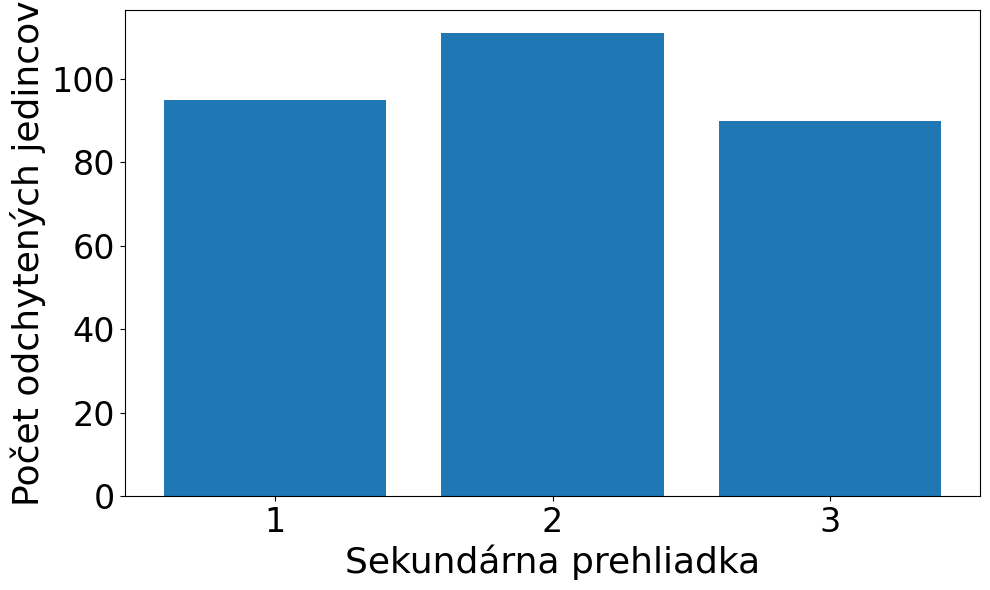

### Analýza pre mesiac 2

**Počet termínov v mesiaci:** 3

**Počet pozorovaných jedincov v mesiaci:** 130

**Počet úplne nulových histórií v tomto mesiaci podľa raw dát:** 715

**Počet odchytení podľa času:** [88, 66, 53]

...

Namiesto grafu Mt zobrazujeme p_t v tabuľke, aby boli jednotlivé pravdepodobnosti zachytenia prehľadne dostupné pre diplomovú prácu.

,prehliadka (t),p_t
0,1,0.568
1,2,0.426
2,3,0.342


#### Mh Jackknife

Mh jackknife uvádzame ako doplnkový odhad heterogenity. Tento odhad nie je priamo porovnávaný pomocou AIC.

,M_unique,f1,f2,Mh_jackknife1,Mh_jackknife2
0,130,71,41,177.333333,194.166667


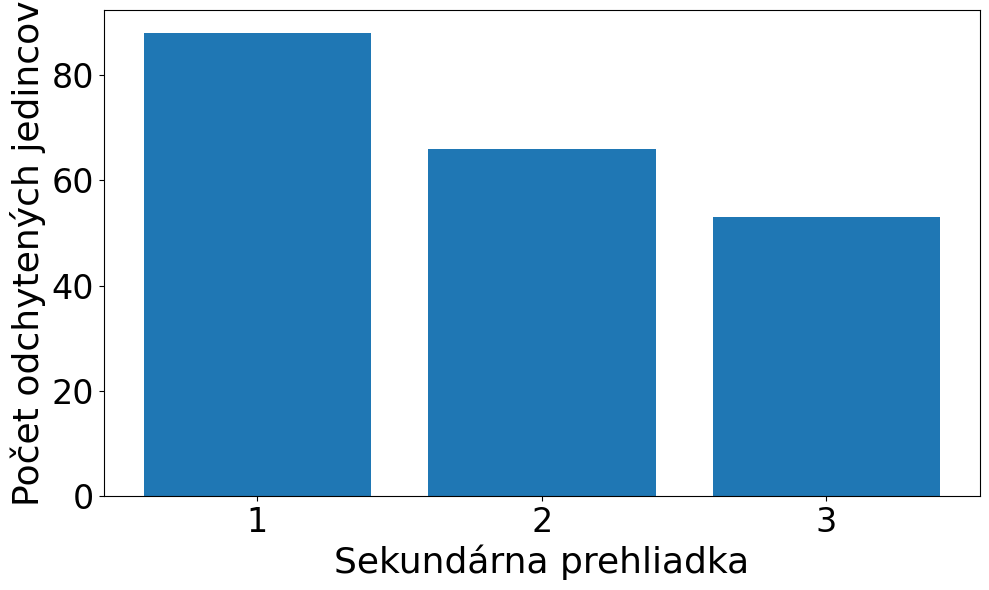

### Analýza pre mesiac 3

**Počet termínov v mesiaci:** 3

**Počet pozorovaných jedincov v mesiaci:** 108

**Počet úplne nulových histórií v tomto mesiaci podľa raw dát:** 737

**Počet odchytení podľa času:** [74, 69, 50]

...

Namiesto grafu Mt zobrazujeme p_t v tabuľke, aby boli jednotlivé pravdepodobnosti zachytenia prehľadne dostupné pre diplomovú prácu.

,prehliadka (t),p_t
0,1,0.627
1,2,0.585
2,3,0.424


#### Mh Jackknife

Mh jackknife uvádzame ako doplnkový odhad heterogenity. Tento odhad nie je priamo porovnávaný pomocou AIC.

,M_unique,f1,f2,Mh_jackknife1,Mh_jackknife2
0,108,47,37,139.333333,148.833333


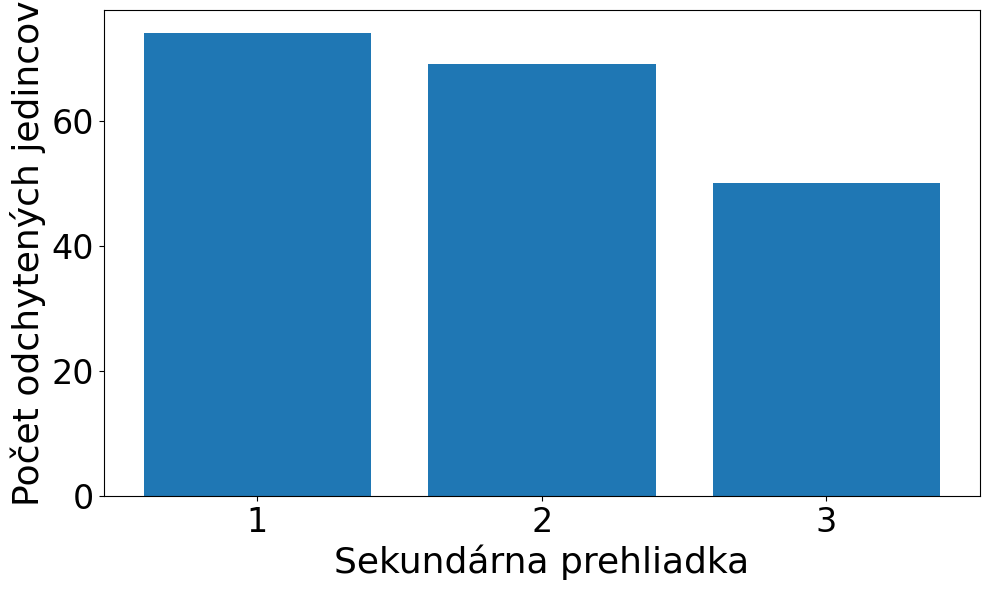

### Analýza pre mesiac 4

**Počet termínov v mesiaci:** 3

**Počet pozorovaných jedincov v mesiaci:** 104

**Počet úplne nulových histórií v tomto mesiaci podľa raw dát:** 741

**Počet odchytení podľa času:** [79, 48, 41]

...

Namiesto grafu Mt zobrazujeme p_t v tabuľke, aby boli jednotlivé pravdepodobnosti zachytenia prehľadne dostupné pre diplomovú prácu.

,prehliadka (t),p_t
0,1,0.664
1,2,0.403
2,3,0.345


#### Mh Jackknife

Mh jackknife uvádzame ako doplnkový odhad heterogenity. Tento odhad nie je priamo porovnávaný pomocou AIC.

,M_unique,f1,f2,Mh_jackknife1,Mh_jackknife2
0,104,52,40,138.666667,149.333333


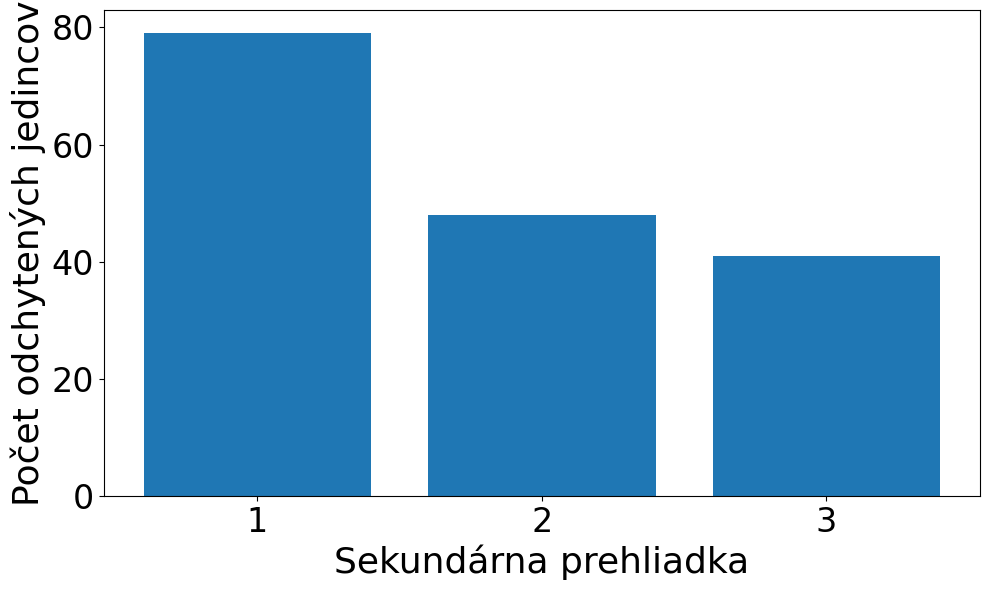

### Analýza pre mesiac 5

**Počet termínov v mesiaci:** 3

**Počet pozorovaných jedincov v mesiaci:** 155

**Počet úplne nulových histórií v tomto mesiaci podľa raw dát:** 690

**Počet odchytení podľa času:** [102, 66, 67]

...

Namiesto grafu Mt zobrazujeme p_t v tabuľke, aby boli jednotlivé pravdepodobnosti zachytenia prehľadne dostupné pre diplomovú prácu.

,prehliadka (t),p_t
0,1,0.523
1,2,0.338
2,3,0.344


#### Mh Jackknife

Mh jackknife uvádzame ako doplnkový odhad heterogenity. Tento odhad nie je priamo porovnávaný pomocou AIC.

,M_unique,f1,f2,Mh_jackknife1,Mh_jackknife2
0,155,96,38,219.0,244.666667


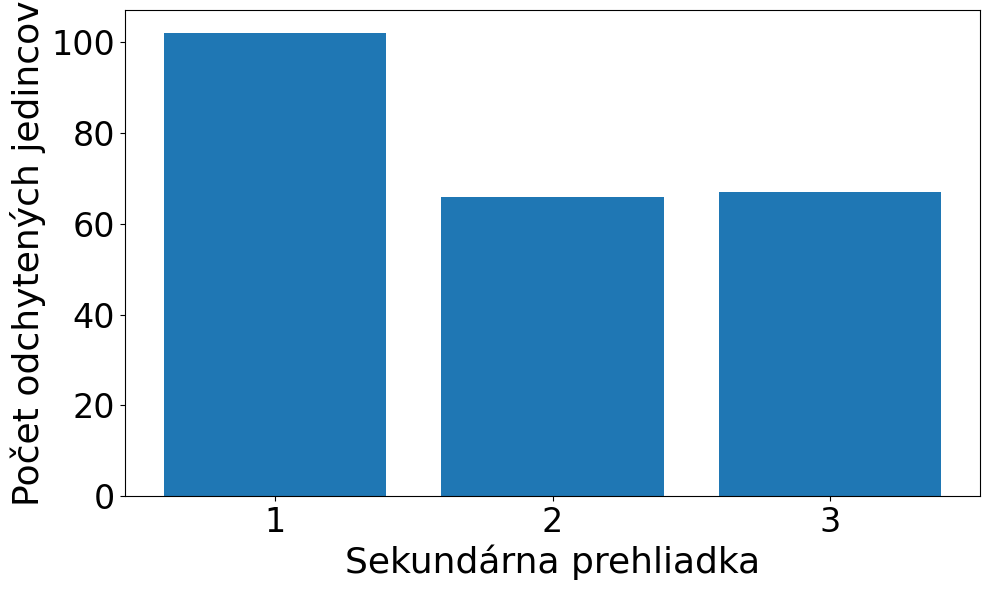

### Analýza pre mesiac 6

**Počet termínov v mesiaci:** 3

**Počet pozorovaných jedincov v mesiaci:** 94

**Počet úplne nulových histórií v tomto mesiaci podľa raw dát:** 751

**Počet odchytení podľa času:** [41, 37, 57]

...

Pre šiesty mesiac uvádzame odhad behaviorálnej pravdepodobnosti zachytenia v modeli Mb.

,parameter,hodnota
0,p,0.182
1,c,0.390


#### Mh Jackknife

Mh jackknife uvádzame ako doplnkový odhad heterogenity. Tento odhad nie je priamo porovnávaný pomocou AIC.

,M_unique,f1,f2,Mh_jackknife1,Mh_jackknife2
0,94,62,23,135.333333,152.166667


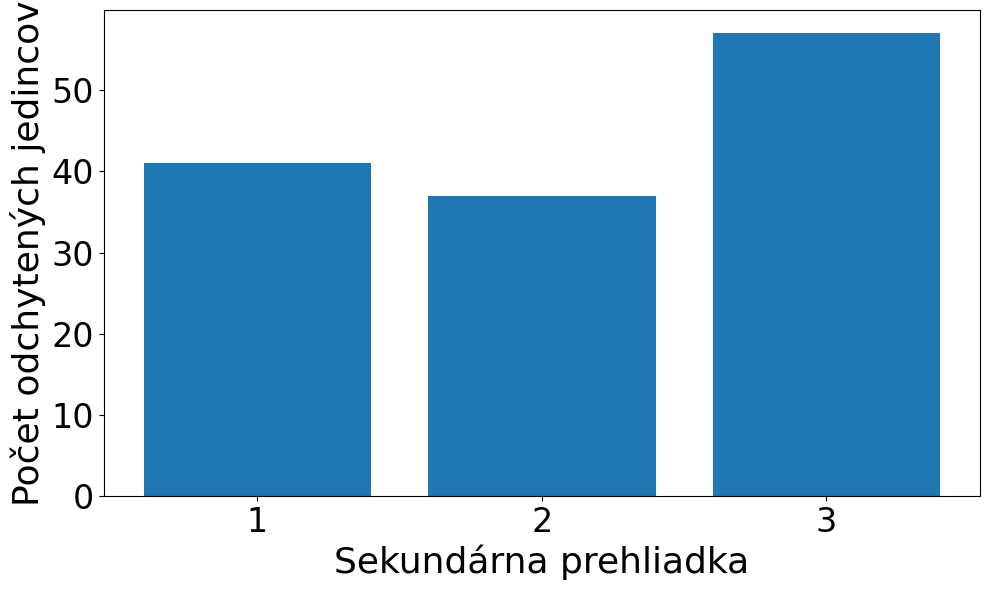

### Analýza pre mesiac 7

**Počet termínov v mesiaci:** 3

**Počet pozorovaných jedincov v mesiaci:** 117

**Počet úplne nulových histórií v tomto mesiaci podľa raw dát:** 728

**Počet odchytení podľa času:** [67, 47, 62]

...

Namiesto grafu Mt zobrazujeme p_t v tabuľke, aby boli jednotlivé pravdepodobnosti zachytenia prehľadne dostupné pre diplomovú prácu.

,prehliadka (t),p_t
0,1,0.447
1,2,0.313
2,3,0.413


#### Mh Jackknife

Mh jackknife uvádzame ako doplnkový odhad heterogenity. Tento odhad nie je priamo porovnávaný pomocou AIC.

,M_unique,f1,f2,Mh_jackknife1,Mh_jackknife2
0,117,73,29,165.666667,185.166667


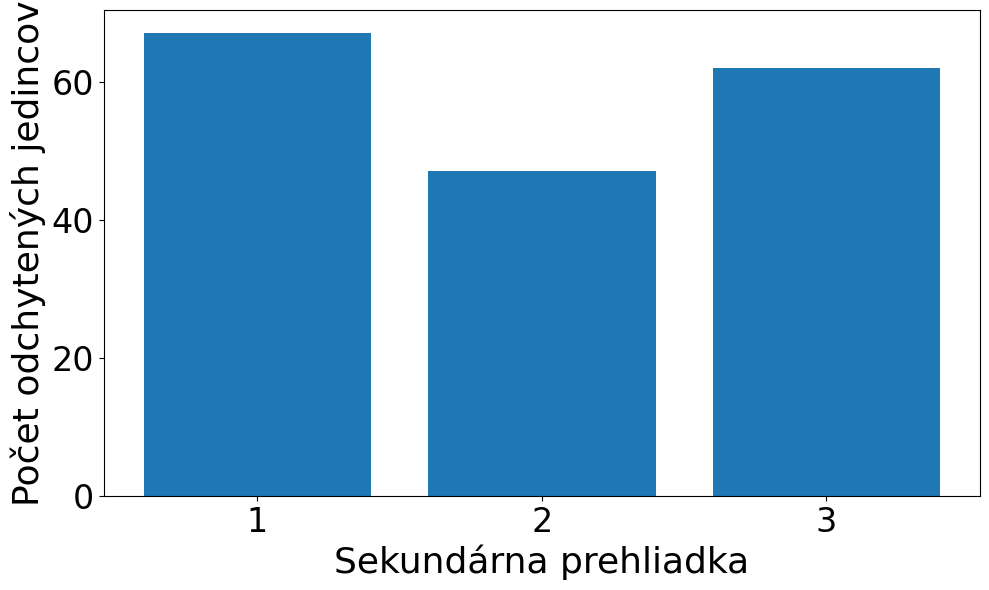

## Súhrnná tabuľka výsledkov po mesiacoch

,month,n_obs,zero_count,M0_N,Mt_N,Mb_N,best_model
0,mesiac 1,210,635,301,300,303,M0
1,mesiac 2,130,715,158,155,138,Mt
2,mesiac 3,108,737,119,118,112,Mt
3,mesiac 4,104,741,124,119,106,Mt
4,mesiac 5,155,690,199,195,168,Mt
5,mesiac 6,94,751,130,128,207,Mt
6,mesiac 7,117,728,151,150,139,Mt


## Celkové závery

Mt bol najlepším modelom v 6/7 mesiacoch, čo naznačuje dominantný časový efekt.

Mb nebol dominantný, čo znamená slabú alebo žiadnu podporu pre silný behaviorálny efekt.

M0 bol najlepší v 1/7 mesiacoch; pevná pravdepodobnosť zachytenia nie je vo všetkých mesiacoch dostatočná.

Mh jackknife je pomocný odhad heterogenity a nie je porovnávaný podľa AIC.

In [102]:
script_dir = Path.cwd()
data_path = script_dir / "capture-recapture-histories.txt"
if not data_path.exists():
    candidates = list(script_dir.glob("*capture-recapture*h*.txt"))
    if candidates:
        data_path = candidates[0]

raw = read_mark_histories(data_path)
T_raw = len(raw["history"].iloc[0])
zero_hist_raw = "0" * T_raw
zero_count_raw = int(raw.loc[raw["history"] == zero_hist_raw, "count"].sum())
observed_raw = raw.loc[raw["history"] != zero_hist_raw].copy()

n_obs_raw = int(observed_raw["count"].sum())
total_captures_raw = int((observed_raw["history"].str.count("1") * observed_raw["count"]).sum())
counts_by_time_raw = [
    int((observed_raw["history"].str[i] == "1").mul(observed_raw["count"]).sum())
    for i in range(T_raw)
]

display(Markdown("## Dáta z 21 sekundárnych prehliadok"))
display(Markdown(f"**Celkový počet riadkov:** {int(raw['count'].sum())}"))
display(Markdown(f"**Pozorovaných jedincov (bez all-zero):** {n_obs_raw}"))
display(Markdown(f"**Úplne nulových histórií:** {zero_count_raw}"))
display(Markdown(f"**Počet prehliadok T_raw:** {T_raw}"))


N_max = max(int(n_obs_raw * 2.5), n_obs_raw + 300)

display(Markdown("## Analýza po mesiacoch (7 mesiacov po 3 sekundárnych prehliadkach)"))
month_results = []
for month in range(7):
    indices = [month * 3, month * 3 + 1, month * 3 + 2]
    result = pt_subset_otis(raw, indices, f"mesiac {month + 1}", N_max)
    month_results.append(result)

    display(Markdown(f"### Analýza pre {result['month']}"))
    display(Markdown(f"**Počet termínov v mesiaci:** {len(indices)}"))
    display(Markdown(f"**Počet pozorovaných jedincov v mesiaci:** {result['n_obs']}"))
    display(Markdown(f"**Počet úplne nulových histórií v tomto mesiaci podľa raw dát:** {result['zero_count']}"))
    display(Markdown(f"**Počet odchytení podľa času:** {result['counts_by_time']}"))

    display(Markdown("#### Párové odhady Lincoln-Petersen"))
    display(result['pair_df'])
    display(Markdown("Poznámka: tabuľka zobrazuje odhady Chapmana pre párové zatáky. Intervaly spoľahlivosti nie sú explicitne uvedené, aby sme sa v tejto analýze sústredili na hlavné odhadované hodnoty populácie."))

    display(Markdown("#### Porovnanie modelov podľa AIC"))
    display(Markdown("V tejto časti používame iba AIC a ΔAIC na výber najlepšieho modelu. AIC váhy nie sú súčasťou teórie, ktorú tu prezentujeme, preto sme ich z tabuľky odstránili."))
    display(result['aic_df'])
    display(Markdown(f"**Najlepší model podľa AIC:** {result['best_model']}"))
    display(Markdown(f"**Interpretácia AIC:** {result['interpretation']}"))

    display(Markdown("#### Tabuľka pravdepodobností Mt"))
       
    if month == 0:
        display(Markdown("#### Parametre modelu M0"))
        display(Markdown("Pre prvý mesiac uvádzame odhad konštantnej pravdepodobnosti zachytenia p v modeli M0."))

        m0_table = pd.DataFrame({
            "parameter": ["p"],
            "hodnota": [round(result["best_m0"]["p"], 3)]
        })
        display(m0_table)

    elif month==5:
        display(Markdown("#### Parametre modelu Mb"))
        display(Markdown("Pre šiesty mesiac uvádzame odhad behaviorálnej pravdepodobnosti zachytenia v modeli Mb."))

        mb_table = pd.DataFrame({
            "parameter": ['p', 'c'],
            "hodnota": [round(result['best_mb']["p"], 3), round(result['best_mb']['c'], 3)],
        })
        display(mb_table)
    else:
        display(Markdown("#### Tabuľka pravdepodobností Mt"))
        display(Markdown("Namiesto grafu Mt zobrazujeme p_t v tabuľke, aby boli jednotlivé pravdepodobnosti zachytenia prehľadne dostupné pre diplomovú prácu."))

        mt_table = pd.DataFrame({
            "prehliadka (t)": list(range(1, len(result['best_mt']["p"]) + 1)),
            "p_t": [round(p_val, 3) for p_val in result['best_mt']["p"]],
        })
        display(mt_table)

    display(Markdown("#### Mh Jackknife"))
    display(Markdown("Mh jackknife uvádzame ako doplnkový odhad heterogenity. Tento odhad nie je priamo porovnávaný pomocou AIC."))
    display(result['mh_df'])

    grafy_dir = script_dir / "grafy"
    plot_capture_frequency(result['counts_by_time'], grafy_dir / f"capture_frequency_{result['month'].replace(' ', '_')}.pdf")

summary_df = pd.DataFrame(month_results)
display(Markdown("## Súhrnná tabuľka výsledkov po mesiacoch"))
display(summary_df[["month", "n_obs", "zero_count", "M0_N", "Mt_N", "Mb_N", "best_model"]])

best_counts = summary_df["best_model"].value_counts().to_dict()
mt_wins = best_counts.get("Mt", 0)
mb_wins = best_counts.get("Mb", 0)
m0_wins = best_counts.get("M0", 0)
comparable_months = sum(
    1
    for row in month_results
    if sorted([row["deltaAIC_M0"], row["deltaAIC_Mt"], row["deltaAIC_Mb"]])[1] < 2
)

display(Markdown("## Celkové závery"))
display(Markdown(f"Mt bol najlepším modelom v {mt_wins}/7 mesiacoch, čo naznačuje dominantný časový efekt."))
if mb_wins > 0:
    display(Markdown(f"Mb bol najlepším modelom v {mb_wins}/7 mesiacoch; to môže naznačovať behaviorálny efekt v týchto mesiacoch."))
else:
    display(Markdown("Mb nebol dominantný, čo znamená slabú alebo žiadnu podporu pre silný behaviorálny efekt."))

if m0_wins > 0:
    display(Markdown(f"M0 bol najlepší v {m0_wins}/7 mesiacoch; pevná pravdepodobnosť zachytenia nie je vo všetkých mesiacoch dostatočná."))
else:
    display(Markdown(f"V {comparable_months}/7 mesiacoch boli aspoň dva modely prakticky porovnateľné (ΔAIC < 2)."))

display(Markdown("Mh jackknife je pomocný odhad heterogenity a nie je porovnávaný podľa AIC."))
